In [5]:
# !pip install -U "langchain[openai]"
# !pip install deepagents tavily-python

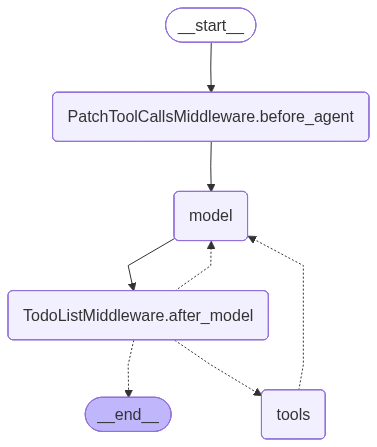

In [6]:
import os
from langchain_openai import ChatOpenAI
from deepagents import create_deep_agent

os.environ["OPENAI_API_KEY"] = "sk-..."

model = ChatOpenAI(model="gpt-4.1")
agent = create_deep_agent(model=model)
agent

# LangChain Deep Agents — Deep Dive

## What are Deep Agents?

Deep Agents is an **agent harness** built on top of **LangChain** and **LangGraph**. Unlike simple tool-calling loops, Deep Agents are equipped with four core capabilities that make them suitable for complex, long-horizon tasks:

| Component | Purpose |
|---|---|
| **Detailed System Prompts** | Guide agent behavior with rich context and examples |
| **Planning Tool** (`write_todos`) | Break complex tasks into manageable steps (context engineering) |
| **Sub-agents** | Spawn isolated agents for specific subtasks — better context management |
| **File System Access** | Persist notes, intermediate results, and share data between agents |

## Architecture Overview

```
User Prompt
    │
    ▼
┌─────────────────────────────────────────┐
│           Deep Agent (Primary)          │
│  ┌───────────┐  ┌──────────────────┐   │
│  │  Planning │  │  File System     │   │
│  │  Tool     │  │  (read/write/    │   │
│  │(write_todo│  │   edit/search)   │   │
│  └───────────┘  └──────────────────┘   │
│  ┌────────────────────────────────────┐ │
│  │         Sub-Agent Spawner          │ │
│  │  ┌──────────┐    ┌──────────────┐ │ │
│  │  │ SubAgent1│    │  SubAgent2   │ │ │
│  │  │(isolated │    │ (isolated    │ │ │
│  │  │ context) │    │  context)    │ │ │
│  │  └──────────┘    └──────────────┘ │ │
│  └────────────────────────────────────┘ │
└─────────────────────────────────────────┘
    │
    ▼
Final Response (with auto-summarization)
```

Real-world examples using this pattern: **Claude Code**, **Deep Research**, **Manus**

In [ ]:
# ============================================================
# SECTION 1: Installation
# ============================================================
# !pip install -qU deepagents langchain-anthropic langchain-openai tavily-python

# ============================================================
# SECTION 2: Basic Deep Agent — Minimal Setup
# ============================================================
import os
from deepagents import create_deep_agent
from langchain_openai import ChatOpenAI

  # Pass API key via environment variable (never hardcode keys)
model = ChatOpenAI(
      model="gpt-4o",
      temperature=0,
      api_key=os.environ["OPENAI_API_KEY"]  # Set with: export OPENAI_API_KEY=your-key
  )

agent = create_deep_agent(model=model)

result = agent.invoke({
      "messages": [{"role": "user", "content": "What are the key steps to build a REST API in Python?"}]
  })

print(result["messages"][-1].content)

In [ ]:
# ============================================================
# SECTION 3: Deep Agent with a Custom Model
# ============================================================
from langchain_openai import ChatOpenAI
from deepagents import create_deep_agent

# Swap in any LangChain-compatible chat model
model = ChatOpenAI(model="gpt-4.1", temperature=0)

agent_with_model = create_deep_agent(model=model)

result = agent_with_model.invoke({
    "messages": [{"role": "user", "content": "Summarize the pros and cons of microservices vs monolith."}]
})

print(result["messages"][-1].content)

In [10]:
# ============================================================
# SECTION 4: Deep Agent with Custom Tools
# ============================================================
from langchain_core.tools import tool
from deepagents import create_deep_agent

# Define your own custom tools using the @tool decorator
@tool
def get_weather(city: str) -> str:
    """Get the current weather for a given city."""
    # Replace with a real API call (e.g., OpenWeatherMap)
    weather_data = {
        "London": "Cloudy, 12°C",
        "New York": "Sunny, 22°C",
        "Tokyo": "Rainy, 18°C",
    }
    return weather_data.get(city, f"Weather data not available for {city}")

@tool
def calculate_bmi(weight_kg: float, height_m: float) -> str:
    """Calculate the Body Mass Index (BMI) given weight in kg and height in meters."""
    bmi = weight_kg / (height_m ** 2)
    if bmi < 18.5:
        category = "Underweight"
    elif bmi < 25:
        category = "Normal weight"
    elif bmi < 30:
        category = "Overweight"
    else:
        category = "Obese"
    return f"BMI: {bmi:.2f} — Category: {category}"

# Pass custom tools to the agent — these augment the built-in deep agent tools
agent_with_tools = create_deep_agent(tools=[get_weather, calculate_bmi])

result = agent_with_tools.invoke({
    "messages": [{"role": "user", "content": "What's the weather in Tokyo? Also, what's the BMI for 70kg and 1.75m height?"}]
})

print(result["messages"][-1].content)

TypeError: "Could not resolve authentication method. Expected either api_key or auth_token to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [ ]:
# ============================================================
# SECTION 5: Deep Agent with Custom System Prompt
# ============================================================
from deepagents import create_deep_agent

# Custom system prompt narrows agent behavior to a specific domain
CUSTOM_SYSTEM_PROMPT = """
You are an expert Python software engineer and code reviewer.
Your job is to:
1. Analyze code for bugs, security issues, and performance problems.
2. Suggest improvements with clear explanations.
3. Provide corrected code snippets when relevant.
Always be concise, technical, and actionable in your responses.
"""

agent_with_prompt = create_deep_agent(system_prompt=CUSTOM_SYSTEM_PROMPT)

code_to_review = """
def fetch_user(user_id):
    query = "SELECT * FROM users WHERE id = " + user_id
    result = db.execute(query)
    return result
"""

result = agent_with_prompt.invoke({
    "messages": [{"role": "user", "content": f"Review this code:\n```python\n{code_to_review}\n```"}]
})

print(result["messages"][-1].content)

In [ ]:
# ============================================================
# SECTION 6: Streaming Responses from a Deep Agent
# ============================================================
# Deep Agents are built on LangGraph, so streaming is natively supported.
from deepagents import create_deep_agent

agent = create_deep_agent()

print("--- Streaming Agent Response ---\n")
for chunk in agent.stream(
    {"messages": [{"role": "user", "content": "Explain how neural networks learn, step by step."}]},
    stream_mode="values"
):
    # Each chunk is the full state; get the last message
    last_msg = chunk["messages"][-1]
    if hasattr(last_msg, "content") and last_msg.content:
        print(last_msg.content, end="", flush=True)

print("\n\n--- Stream Complete ---")

In [ ]:
# ============================================================
# SECTION 7: Inspecting Built-in Deep Agent Tools
# ============================================================
# Deep Agents come with a rich set of built-in tools out of the box.
from deepagents import create_deep_agent

agent = create_deep_agent()

# LangGraph compiles the agent — we can inspect bound tools via the graph
print("Built-in Deep Agent Tools:\n")
print(f"{'Tool Name':<30} {'Description'}")
print("-" * 80)

# Access the agent's tools through the compiled graph's nodes
try:
    # Get tools from the compiled graph
    graph = agent
    # The tools are accessible via the agent's nodes
    for node_name, node in graph.nodes.items():
        if hasattr(node, 'tools'):
            for t in node.tools:
                desc = (t.description[:60] + "...") if len(t.description) > 60 else t.description
                print(f"{t.name:<30} {desc}")
except AttributeError:
    # Fallback: show known built-in tools from documentation
    builtin_tools = [
        ("write_todos",     "Plan tasks by writing a TODO list (planning strategy)"),
        ("read_file",       "Read contents of a file from the filesystem"),
        ("write_file",      "Write content to a file on the filesystem"),
        ("edit_file",       "Edit an existing file by replacing text"),
        ("list_directory",  "List files and folders in a directory"),
        ("search_files",    "Search file contents with regex patterns"),
        ("run_command",     "Execute shell commands in a sandbox"),
        ("spawn_subagent",  "Delegate subtasks to an isolated sub-agent"),
    ]
    for name, desc in builtin_tools:
        print(f"{name:<30} {desc}")

print("\nAll these tools are available to the agent automatically.")

## Deep Agents vs. Standard LangChain Agents — Quick Comparison

| Feature | Standard LangChain Agent | Deep Agent |
|---|---|---|
| **Setup** | Manual tool wiring + prompt | Single `create_deep_agent()` call |
| **Planning** | No built-in planning | `write_todos` planning tool included |
| **File System** | Manual file tools | Built-in read/write/edit/search |
| **Sub-agents** | Not available | Native sub-agent spawning |
| **Context Mgmt** | Manual | Auto-summarization built in |
| **Runtime** | Custom loop | LangGraph (streaming, checkpointing) |
| **Model Support** | LangChain compatible | Same (provider-agnostic) |
| **Use Case** | Simple tool use | Complex, multi-step, long-horizon tasks |

## Key Takeaways

1. **Deep Agents = Agent Harness** — not just an agent, but a framework for building production-ready agents fast.
2. **Planning is context engineering** — `write_todos` keeps the agent on track for complex tasks.
3. **Sub-agents solve the context window problem** — delegate deep subtasks to isolated agents.
4. **File system = agent memory** — agents can persist work, share results, and pick up where they left off.
5. **Built on LangGraph** — all production features (streaming, checkpointing, human-in-the-loop) work out of the box.

## Resources
- [deepagents GitHub](https://github.com/langchain-ai/deepagents)
- [LangChain Deep Agents Blog Post](https://blog.langchain.com/deep-agents/)
- [Deep Agents Docs](https://docs.langchain.com/oss/python/deepagents/overview)